# Steps 6 & 7 — Benchmark & HPC Optimization

Same cleaning logic across four engines, benchmarked on the same `raw_data.csv`:

1. **pandas** — single-threaded baseline (step 6).
2. **Polars** — vectorised, multi-threaded Rust engine.
3. **Multiprocessing** — pandas split across CPU cores via `Pool.map`.
4. **PySpark** — distributed DataFrame on `local[*]`.

Each engine runs `REPEATS` times; per-run and averaged metrics are saved to `benchmark_runs.csv` / `benchmark_results.csv`, and comparison charts are saved as PNGs.

In [1]:
import os
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cleaners, worker, benchmark_utils
importlib.reload(cleaners)
importlib.reload(worker)
importlib.reload(benchmark_utils)
from cleaners import clean_pandas, clean_polars, clean_pyspark
from worker import clean_multiprocessing
from benchmark_utils import benchmark

RAW = 'raw_data.csv'
RESULTS = 'benchmark_results.csv'
RUNS = 'benchmark_runs.csv'
REPEATS = 5
sns.set_theme(style='whitegrid')

## Load raw data once

In [2]:
raw_df = pd.read_csv(RAW)
n_rows = len(raw_df)
print(f'rows: {n_rows}')

rows: 200033


C:\Users\user\AppData\Local\Temp\ipykernel_29944\1460528293.py:1: DtypeWarning: Columns (0: likes) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(RAW)


## Pandas — baseline (Step 6)

In [3]:
pandas_m = benchmark(clean_pandas, raw_df, repeats=REPEATS, n_rows=n_rows)
pandas_m['engine'] = 'pandas'
print('Per-run metrics:')
display(pandas_m['runs_df'])
print('\nAverage:')
{k: v for k, v in pandas_m.items() if k not in ('runs', 'runs_df')}

Per-run metrics:


,run,wall_time_s,cpu_pct,peak_mem_mb,rss_mem_mb,rows_out,throughput_rps
0,1,24.277955,98.033824,64.534581,253.546875,198429,8239.285359
1,2,23.758575,98.732000,64.507661,260.710938,198429,8419.402400
2,3,23.510892,98.646193,64.506273,261.335938,198429,8508.098995
3,4,23.455460,98.694416,64.507097,267.140625,198429,8528.206189
4,5,23.859914,98.766667,64.506579,267.179688,198429,8383.642924



Average:


{'wall_time_s': np.float64(23.77255925999925),
 'cpu_pct': np.float64(98.57461986662686),
 'peak_mem_mb': np.float64(64.51243839263915),
 'rss_mem_mb': np.float64(261.9828125),
 'rows_out': np.float64(198429.0),
 'throughput_rps': np.float64(8415.72717330037),
 'engine': 'pandas'}

## Polars

In [4]:
polars_m = benchmark(clean_polars, RAW, repeats=REPEATS, n_rows=n_rows)
polars_m['engine'] = 'polars'
print('Per-run metrics:')
display(polars_m['runs_df'])
print('\nAverage:')
{k: v for k, v in polars_m.items() if k not in ('runs', 'runs_df')}

Per-run metrics:


,run,wall_time_s,cpu_pct,peak_mem_mb,rss_mem_mb,rows_out,throughput_rps
0,1,21.990241,98.148485,8.614867,482.812500,198429,9096.444191
1,2,20.663609,103.884783,0.047200,623.457031,198429,9680.448367
2,3,20.482054,103.577108,0.046695,677.171875,198429,9766.257032
3,4,19.984933,104.953165,0.046213,683.609375,198429,10009.190524
4,5,19.946454,104.262195,0.046008,652.664062,198429,10028.499251



Average:


{'wall_time_s': np.float64(20.613458099999114),
 'cpu_pct': np.float64(102.96514711396574),
 'peak_mem_mb': np.float64(1.7601966857910156),
 'rss_mem_mb': np.float64(623.94296875),
 'rows_out': np.float64(198429.0),
 'throughput_rps': np.float64(9716.167872895352),
 'engine': 'polars'}

## Multiprocessing

In [5]:
mp_m = benchmark(clean_multiprocessing, raw_df, repeats=REPEATS, n_rows=n_rows)
mp_m['engine'] = 'multiprocessing'
print('Per-run metrics:')
display(mp_m['runs_df'])
print('\nAverage:')
{k: v for k, v in mp_m.items() if k not in ('runs', 'runs_df')}

Per-run metrics:


,run,wall_time_s,cpu_pct,peak_mem_mb,rss_mem_mb,rows_out,throughput_rps
0,1,3.597777,39.156250,106.474732,737.015625,198429,55599.053093
1,2,4.099201,32.335135,102.415161,780.964844,198429,48798.051015
2,3,3.368225,37.137500,102.415527,778.898438,198429,59388.255220
3,4,3.382623,33.984375,102.413923,797.738281,198429,59135.471471
4,5,3.609511,37.761765,102.413262,796.871094,198429,55418.308590



Average:


{'wall_time_s': np.float64(3.61146732000343),
 'cpu_pct': np.float64(36.075004968203494),
 'peak_mem_mb': np.float64(103.22652130126953),
 'rss_mem_mb': np.float64(778.29765625),
 'rows_out': np.float64(198429.0),
 'throughput_rps': np.float64(55667.8278778706),
 'engine': 'multiprocessing'}

## PySpark
Requires Java + `winutils` on Windows. If this cell errors, install Java 11/17 and set `JAVA_HOME`, then re-run.

In [6]:
spark_m = benchmark(clean_pyspark, RAW, repeats=REPEATS, n_rows=n_rows)
spark_m['engine'] = 'pyspark'
print('Per-run metrics:')
display(spark_m['runs_df'])
print('\nAverage:')
{k: v for k, v in spark_m.items() if k not in ('runs', 'runs_df')}

Per-run metrics:


,run,wall_time_s,cpu_pct,peak_mem_mb,rss_mem_mb,rows_out,throughput_rps
0,1,27.025601,3.026022,9.067127,733.265625,198429,7401.611394
1,2,1.564342,6.220000,0.134989,733.265625,198429,127870.400694
2,3,1.439940,6.678571,0.132441,733.265625,198429,138917.564846
3,4,1.446963,6.220000,0.133745,733.296875,198429,138243.370061
4,5,1.407815,6.671429,0.130663,733.296875,198429,142087.551127



Average:


{'wall_time_s': np.float64(6.576932259999739),
 'cpu_pct': np.float64(5.763204460966543),
 'peak_mem_mb': np.float64(1.919792938232422),
 'rss_mem_mb': np.float64(733.278125),
 'rows_out': np.float64(198429.0),
 'throughput_rps': np.float64(110904.09962442235),
 'engine': 'pyspark'}

## Persist results (averages + per-run)

In [7]:
cols = ['engine', 'wall_time_s', 'cpu_pct', 'peak_mem_mb', 'rss_mem_mb', 'rows_out', 'throughput_rps']

def _scalar(m):
    return {k: v for k, v in m.items() if k not in ('runs', 'runs_df')}

engines = (pandas_m, polars_m, mp_m, spark_m)

results = pd.DataFrame([_scalar(m) for m in engines])[cols]
results.to_csv(RESULTS, index=False)

per_run = pd.concat([m['runs_df'].assign(engine=m['engine']) for m in engines], ignore_index=True)
per_run = per_run[['engine', 'run', 'wall_time_s', 'cpu_pct', 'peak_mem_mb', 'rss_mem_mb', 'rows_out', 'throughput_rps']]
per_run.to_csv(RUNS, index=False)

print('Per-run results:')
display(per_run)
print('\nAveraged results:')
results

Per-run results:


,engine,run,wall_time_s,cpu_pct,peak_mem_mb,rss_mem_mb,rows_out,throughput_rps
0,pandas,1,24.277955,98.033824,64.534581,253.546875,198429,8239.285359
1,pandas,2,23.758575,98.732000,64.507661,260.710938,198429,8419.402400
2,pandas,3,23.510892,98.646193,64.506273,261.335938,198429,8508.098995
3,pandas,4,23.455460,98.694416,64.507097,267.140625,198429,8528.206189
4,pandas,5,23.859914,98.766667,64.506579,267.179688,198429,8383.642924
5,polars,1,21.990241,98.148485,8.614867,482.812500,198429,9096.444191
6,polars,2,20.663609,103.884783,0.047200,623.457031,198429,9680.448367
7,polars,3,20.482054,103.577108,0.046695,677.171875,198429,9766.257032
8,polars,4,19.984933,104.953165,0.046213,683.609375,198429,10009.190524
9,polars,5,19.946454,104.262195,0.046008,652.664062,198429,10028.499251



Averaged results:


,engine,wall_time_s,cpu_pct,peak_mem_mb,rss_mem_mb,rows_out,throughput_rps
0,pandas,23.772559,98.574620,64.512438,261.982813,198429.0,8415.727173
1,polars,20.613458,102.965147,1.760197,623.942969,198429.0,9716.167873
2,multiprocessing,3.611467,36.075005,103.226521,778.297656,198429.0,55667.827878
3,pyspark,6.576932,5.763204,1.919793,733.278125,198429.0,110904.099624


## Visualisations

C:\Users\user\AppData\Local\Temp\ipykernel_29944\2955186735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='engine', y=metric, ax=ax, palette=palette)


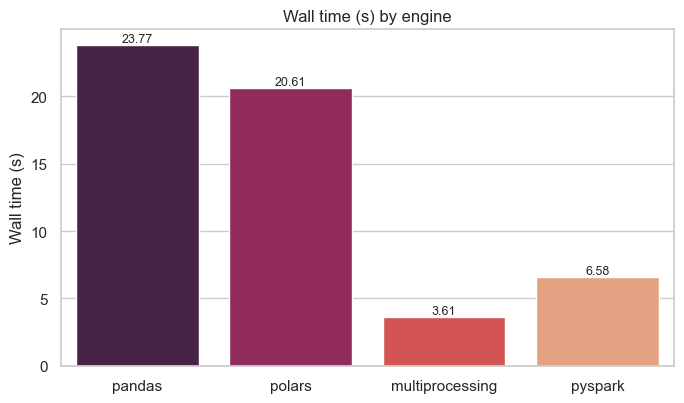

C:\Users\user\AppData\Local\Temp\ipykernel_29944\2955186735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='engine', y=metric, ax=ax, palette=palette)


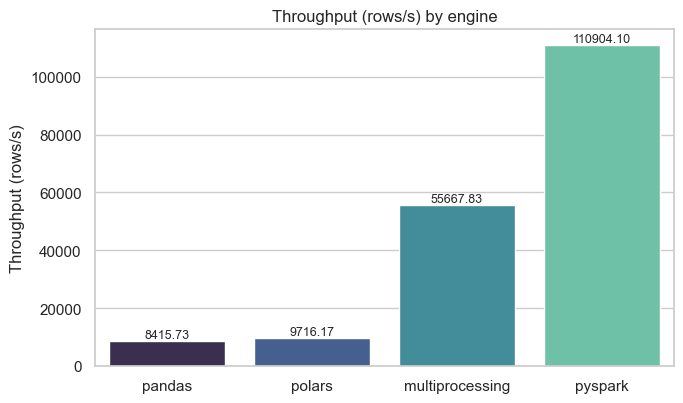

C:\Users\user\AppData\Local\Temp\ipykernel_29944\2955186735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='engine', y=metric, ax=ax, palette=palette)


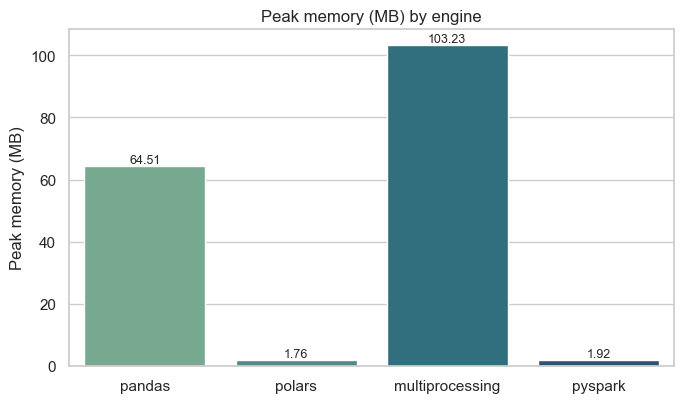

In [8]:
def bar(metric, ylabel, fname, palette='viridis'):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    sns.barplot(data=results, x='engine', y=metric, ax=ax, palette=palette)
    ax.set_title(f'{ylabel} by engine')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()

bar('wall_time_s', 'Wall time (s)', 'fig_time.png', 'rocket')
bar('throughput_rps', 'Throughput (rows/s)', 'fig_throughput.png', 'mako')
bar('peak_mem_mb', 'Peak memory (MB)', 'fig_memory.png', 'crest')

In [9]:
# Speedup vs pandas baseline
base = results.loc[results['engine'] == 'pandas', 'wall_time_s'].iloc[0]
speedup = results.assign(speedup=base / results['wall_time_s'])[['engine', 'wall_time_s', 'speedup']]
speedup

,engine,wall_time_s,speedup
0,pandas,23.772559,1.000000
1,polars,20.613458,1.153254
2,multiprocessing,3.611467,6.582521
3,pyspark,6.576932,3.614536


## Interpretation
- **Polars** typically delivers the largest single-machine speedup thanks to Rust + multi-threaded execution with low overhead.
- **Multiprocessing** scales pandas across cores but pays serialization cost for the chunk transfer; gains are real but smaller than Polars.
- **PySpark** shines on much larger datasets; on ~290k rows the JVM startup and task overhead can make it *slower* than the baseline. Note that `tracemalloc` does not see JVM memory, so the peak-memory bar understates Spark's true footprint.